In [1]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

2026-04-03 12:57:24.576659: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775221044.807149      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775221044.871090      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775221045.397517      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775221045.397579      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775221045.397583      55 computation_placer.cc:177] computation placer alr

In [2]:
DATASET_PATH = "/kaggle/input/datasets/shashankrapolu/human-action-recognition-dataset"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
TEST_DIR = os.path.join(DATASET_PATH, "test")

In [3]:
IMG_SIZE = (224, 224)
SEQUENCE_LENGTH = 5
BATCH_SIZE = 8
EPOCHS = 10
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [6]:
TRAIN_DIR = "/kaggle/input/datasets/shashankrapolu/human-action-recognition-dataset/Structured/train"
TEST_DIR = "/kaggle/input/datasets/shashankrapolu/human-action-recognition-dataset/Structured/test"

class_names = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
num_classes = len(class_names)
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['calling', 'clapping', 'cycling', 'dancing', 'drinking', 'eating', 'fighting', 'hugging', 'laughing', 'listening_to_music', 'running', 'sitting', 'sleeping', 'texting', 'using_laptop']
Number of classes: 15


In [7]:
def get_class_image_paths(root_dir):
    data = {}
    for class_name in sorted(os.listdir(root_dir)):
        class_path = os.path.join(root_dir, class_name)
        if os.path.isdir(class_path):
            images = []
            for file in os.listdir(class_path):
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    images.append(os.path.join(class_path, file))
            if len(images) > 0:
                data[class_name] = images
    return data

train_data = get_class_image_paths(TRAIN_DIR)
test_data = get_class_image_paths(TEST_DIR)

for k, v in train_data.items():
    print(f"{k}: {len(v)} training images")

calling: 714 training images
clapping: 714 training images
cycling: 714 training images
dancing: 714 training images
drinking: 714 training images
eating: 714 training images
fighting: 714 training images
hugging: 714 training images
laughing: 714 training images
listening_to_music: 714 training images
running: 714 training images
sitting: 714 training images
sleeping: 714 training images
texting: 714 training images
using_laptop: 714 training images


In [8]:
def build_sequences(data_dict, sequence_length=5, shuffle=True):
    sequences = []
    labels = []
    
    for class_name, img_paths in data_dict.items():
        img_paths = img_paths.copy()
        if shuffle:
            random.shuffle(img_paths)
        
        n_sequences = len(img_paths) // sequence_length
        
        for i in range(n_sequences):
            seq = img_paths[i * sequence_length:(i + 1) * sequence_length]
            if len(seq) == sequence_length:
                sequences.append(seq)
                labels.append(class_to_idx[class_name])
    
    combined = list(zip(sequences, labels))
    if shuffle:
        random.shuffle(combined)
    
    sequences, labels = zip(*combined)
    return list(sequences), list(labels)

train_sequences, train_labels = build_sequences(train_data, sequence_length=SEQUENCE_LENGTH, shuffle=True)
test_sequences, test_labels = build_sequences(test_data, sequence_length=SEQUENCE_LENGTH, shuffle=False)

print("Train sequences:", len(train_sequences))
print("Test sequences:", len(test_sequences))

Train sequences: 2130
Test sequences: 375


In [9]:
def load_and_preprocess_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img = image.img_to_array(img)
    img = img / 255.0
    return img

In [10]:
class SequenceGenerator(tf.keras.utils.Sequence):
    def __init__(self, sequences, labels, batch_size, num_classes, shuffle=True):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.num_classes = num_classes
        self.shuffle = shuffle
        self.indices = np.arange(len(self.sequences))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        
        batch_x = []
        batch_y = []
        
        for i in batch_indices:
            seq_paths = self.sequences[i]
            seq_images = [load_and_preprocess_image(p) for p in seq_paths]
            batch_x.append(seq_images)
            batch_y.append(self.labels[i])
        
        batch_x = np.array(batch_x, dtype=np.float32)
        batch_y = tf.keras.utils.to_categorical(batch_y, num_classes=self.num_classes)
        
        return batch_x, batch_y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [11]:
train_gen = SequenceGenerator(
    train_sequences, train_labels,
    batch_size=BATCH_SIZE,
    num_classes=num_classes,
    shuffle=True
)

test_gen = SequenceGenerator(
    test_sequences, test_labels,
    batch_size=BATCH_SIZE,
    num_classes=num_classes,
    shuffle=False
)

In [12]:
base_cnn = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_cnn.trainable = False  # freeze CNN for faster training

model = models.Sequential([
    layers.Input(shape=(SEQUENCE_LENGTH, 224, 224, 3)),
    
    layers.TimeDistributed(base_cnn),
    layers.TimeDistributed(layers.GlobalAveragePooling2D()),
    
    layers.LSTM(128, return_sequences=False),
    layers.Dropout(0.3),
    
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    
    layers.Dense(num_classes, activation="softmax")
])

model.summary()

I0000 00:00:1775221289.118193      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775221289.124132      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 5, 7, 7, 1280)  │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 5, 1280)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,988,623 (11.40 MB)

 Trainable params: 730,639 (2.79 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=EPOCHS
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1775221338.537474     138 cuda_dnn.cc:529] Loaded cuDNN version 91002


267/267 ━━━━━━━━━━━━━━━━━━━━ 104s 306ms/step - accuracy: 0.1784 - loss: 2.4377 - val_accuracy: 0.6347 - val_loss: 1.2861
Epoch 2/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 25s 92ms/step - accuracy: 0.5042 - loss: 1.4360 - val_accuracy: 0.7947 - val_loss: 0.7372
Epoch 3/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 25s 93ms/step - accuracy: 0.7316 - loss: 0.8238 - val_accuracy: 0.8613 - val_loss: 0.4639
Epoch 4/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 25s 95ms/step - accuracy: 0.8182 - loss: 0.5662 - val_accuracy: 0.8827 - val_loss: 0.3795
Epoch 5/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 26s 96ms/step - accuracy: 0.8579 - loss: 0.4565 - val_accuracy: 0.9173 - val_loss: 0.2899
Epoch 6/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 27s 100ms/step - accuracy: 0.8685 - loss: 0.3812 - val_accuracy: 0.8720 - val_loss: 0.3355
Epoch 7/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 26s 97ms/step - accuracy: 0.8843 - loss: 0.3025 - val_accuracy: 0.8693 - val_loss: 0.3605
Epoch 8/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 26s 98ms/step - accuracy: 0.9273 - loss: 0.2339 - val_accu

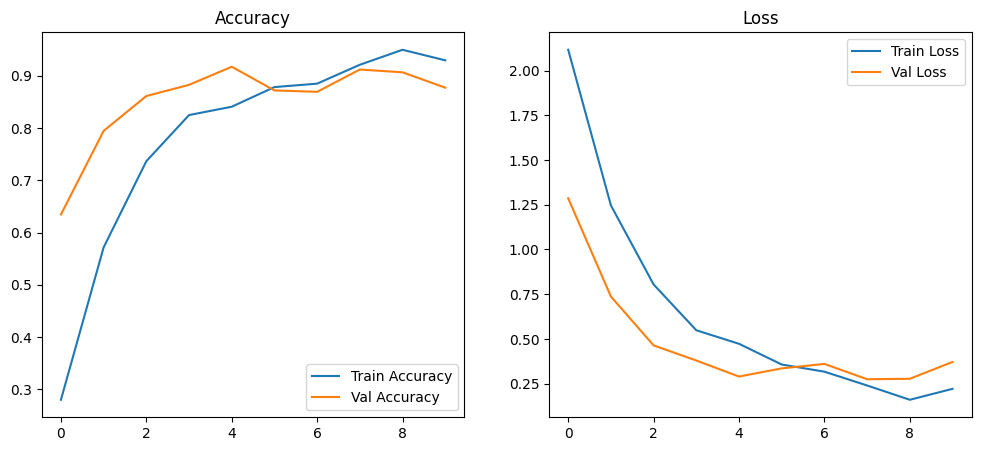

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()

plt.show()

In [16]:
loss, acc = model.evaluate(test_gen)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {acc:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.8962 - loss: 0.3583
Test Loss: 0.3714
Test Accuracy: 0.8773
